## Crear y añadir vectores a la base de datos

In [ ]:
import io
from PIL import Image
import numpy as np
import torch
import timm
import sqlite3
import pandas as pd

c:\Users\evrio\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
db_path = r"C:\Users\evrio\Desktop\TFG\artworks.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [3]:
resnet50_model = timm.create_model('resnet50',pretrained=True,num_classes=0)
resnet50_model.default_cfg

{'url': 'https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-rsb-weights/resnet50_a1_0-14fe96d1.pth',
 'hf_hub_id': 'timm/resnet50.a1_in1k',
 'architecture': 'resnet50',
 'tag': 'a1_in1k',
 'custom_load': False,
 'input_size': (3, 224, 224),
 'test_input_size': (3, 288, 288),
 'fixed_input_size': False,
 'interpolation': 'bicubic',
 'crop_pct': 0.95,
 'test_crop_pct': 1.0,
 'crop_mode': 'center',
 'mean': (0.485, 0.456, 0.406),
 'std': (0.229, 0.224, 0.225),
 'num_classes': 1000,
 'pool_size': (7, 7),
 'first_conv': 'conv1',
 'classifier': 'fc',
 'license': 'apache-2.0',
 'origin_url': 'https://github.com/huggingface/pytorch-image-models',
 'paper_ids': 'arXiv:2110.00476'}

In [ ]:
from timm.data import create_transform

def create_pipeline(model):
  config = model.default_cfg
  # Creación automática de pipeline de preprocesado
  transform = create_transform(
    input_size=config['input_size'],
    interpolation=config['interpolation'],
    mean=config['mean'],
    std=config['std'],
    crop_pct=config['crop_pct']
  )
  return transform

In [ ]:
# Algunas imágenes eran demasiado grandes y se producía un error
# Increase the maximum image pixel limit to avoid DecompressionBombError
# Set to a value greater than the largest image pixel count (e.g., 1 billion pixels)
Image.MAX_IMAGE_PIXELS = 1_000_000_000

def get_embedding(blob, model, transform):
    # 1. Convert blob to PIL and ensure RGB (as expected by the model)
    img = Image.open(io.BytesIO(blob)).convert('RGB')
    # 2. Preprocess with transform pipeline
    img_tensor = transform(img).unsqueeze(0) # Add batch dimension: [1, 3, 224, 224]
    # 3. Extract features (no gradients needed)
    with torch.no_grad():
        embedding_raw = model(img_tensor) # Shape: [1, 512]
    # 4. Flatten and convert to a simple list/numpy array
    # detach from pytorch
    # move to cpu because numpy is on cpu
    embedding = embedding_raw.detach().cpu().squeeze().numpy()
    return embedding

In [6]:
query = "SELECT image_blob, movement FROM artworks WHERE image_blob IS NOT NULL"
image_list = pd.read_sql_query(query, conn)
print(f"Procesando {len(image_list)} imágenes...")
print(image_list.head())

Procesando 127 imágenes...
                                          image_blob       movement
0  b'\xff\xd8\xff\xe1 LExif\x00\x00MM\x00*\x00\x0...   Renacimiento
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x01...   Renacimiento
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...   Renacimiento
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...  neoclasicismo
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x01...  neoclasicismo


In [7]:
resnet50_transform = create_pipeline(resnet50_model)
#resnet50_features_list = process_images(image_list, resnet50_model, resnet50_transform)

Añadimos nueva columna para guardar los vectores

In [9]:
# Añadimos la nueva columna
cursor.execute("ALTER TABLE artworks ADD COLUMN image_embedding")

Procesado de imágenes y guardado de vectores resultantes

In [10]:
cursor.execute("SELECT painting, image_blob FROM artworks WHERE image_blob IS NOT NULL")
rows = cursor.fetchall()
for painting, image_blob in rows:
    embedding = get_embedding(image_blob, resnet50_model, resnet50_transform)
    cursor.execute("UPDATE artworks SET image_embedding = ? WHERE painting = ?", (embedding, painting))
conn.commit()

Código de prueba para comparación de nuevo vector con los de la bbdd

In [14]:
# Obtener lista de vectores
def get_db_embeddings():
    cursor.execute("SELECT painting, image_embedding FROM artworks")
    embeddings_list = cursor.fetchall()
    return embeddings_list

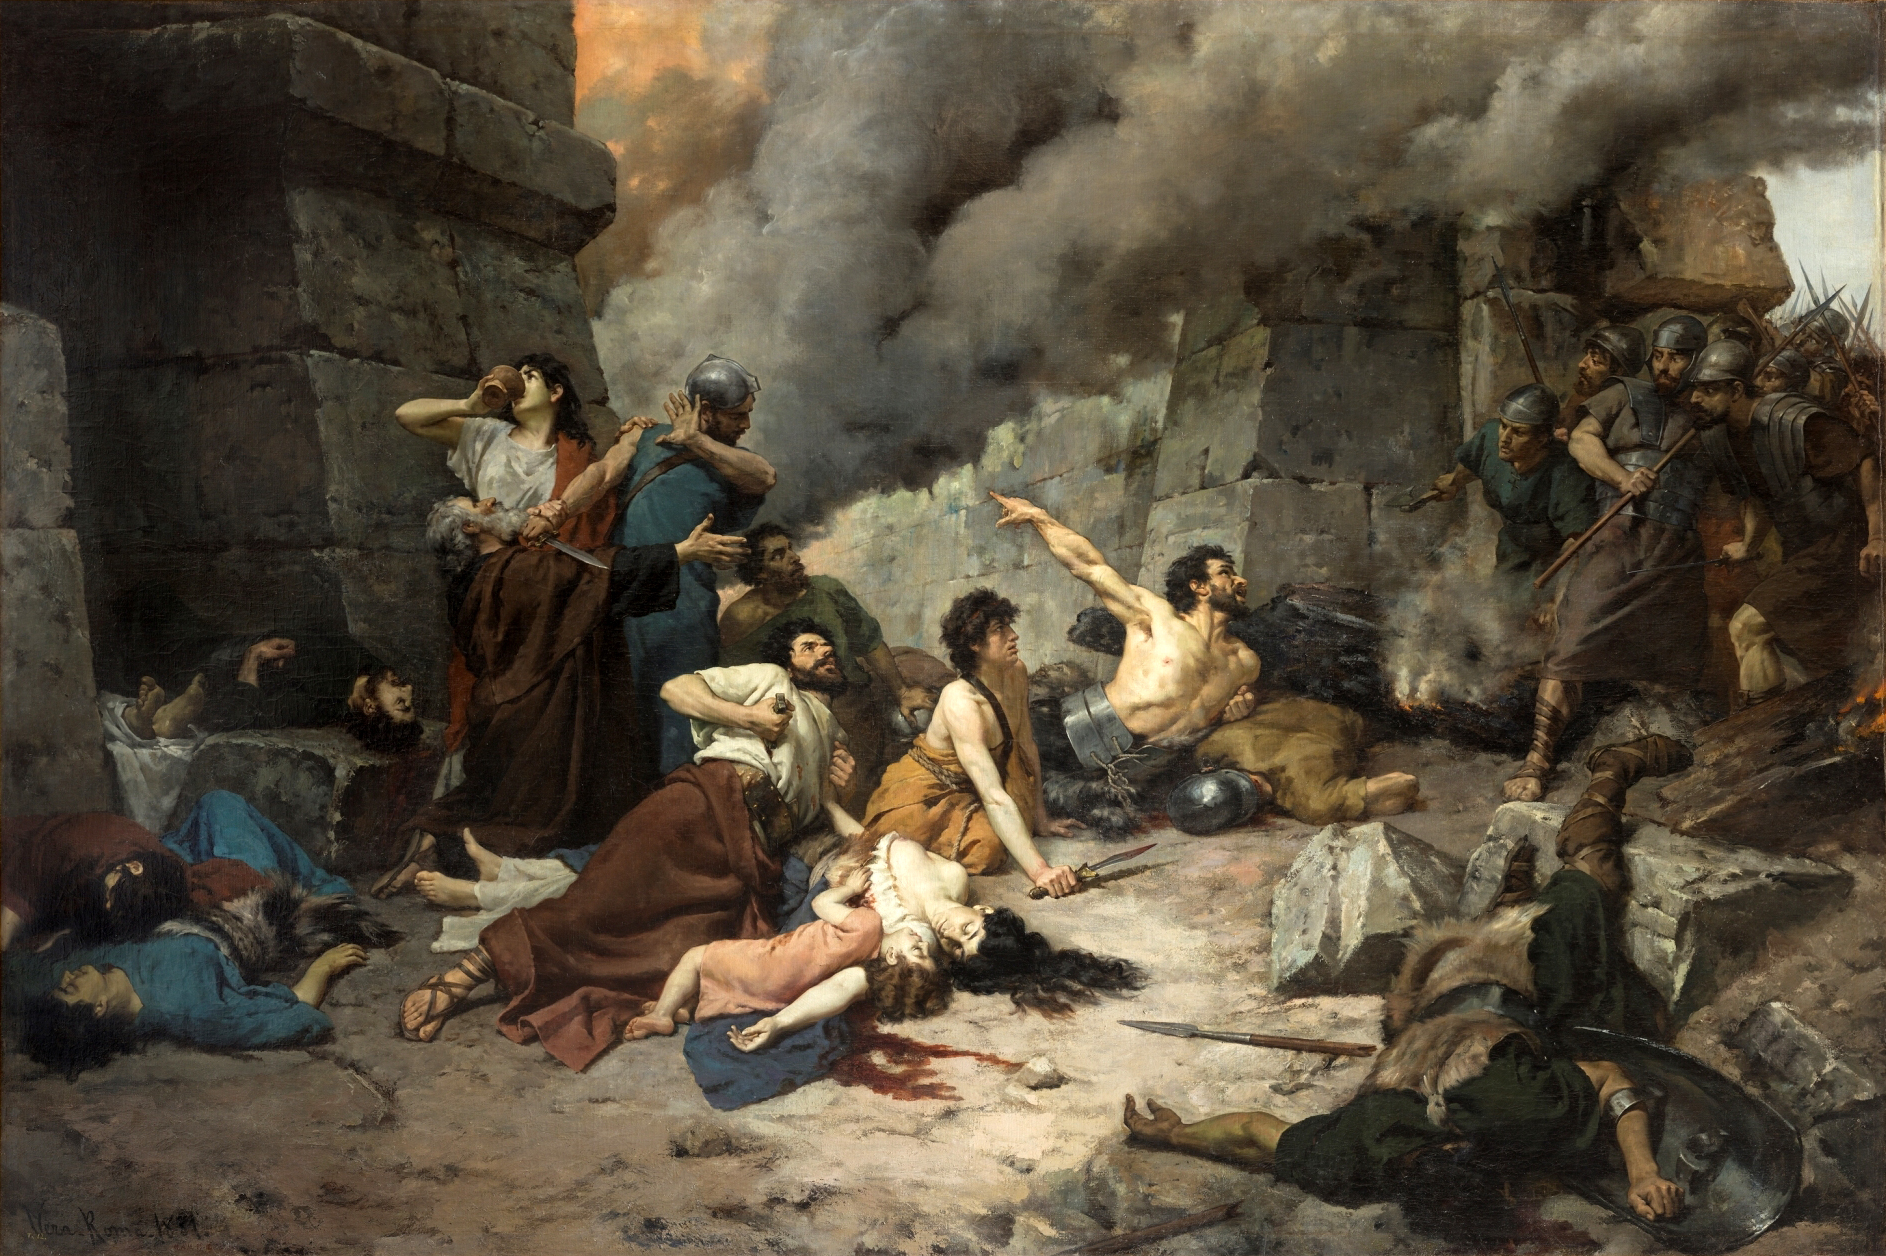

In [11]:
# "Nuevo vector"
cursor = conn.cursor()
cursor.execute("SELECT image_blob FROM artworks WHERE painting = 'El último día de Numancia' LIMIT 1")
new_blob = cursor.fetchone()[0]
Image.MAX_IMAGE_PIXELS = None
# Display the image
image = Image.open(io.BytesIO(new_blob))
display(image)

In [12]:
resnet50_transform = create_pipeline(resnet50_model)
new_embedding = get_embedding(new_blob, resnet50_model, resnet50_transform)

In [ ]:
def get_closest_embedding(new_embedding, embedding_list):
    closest_distance = float('inf')
    closest_embedding = None
    closest_painting = None
    for painting, emb in embedding_list:
        emb = np.frombuffer(emb, dtype=np.float32)
        euclidean_distance = np.linalg.norm(new_embedding - emb)
        if euclidean_distance < closest_distance:
            closest_embedding = emb
            closest_distance = euclidean_distance
            closest_painting = painting
    print("The closest painting is ", closest_painting)
    return closest_embedding

db_embedding_list = get_db_embeddings()
result = get_closest_embedding(new_embedding,db_embedding_list)

The closest painting is  El último día de Numancia


In [16]:
conn.close()